In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, global_add_pool
from pymatgen.core import Structure
from scipy.spatial.distance import cdist
from matbench.bench import MatbenchBenchmark
from sklearn.metrics import mean_absolute_error
import math
np.math = math

# Load Matbench dataset
mb = MatbenchBenchmark(autoload=False)
task = mb.matbench_phonons
task.load()

print(f"✅ Dataset: {len(task.df)} samples")
print(f"   Target range: [{task.df['last phdos peak'].min():.1f}, {task.df['last phdos peak'].max():.1f}] cm⁻¹")

c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\torch_geometric\typing.py:124

2025-10-14 16:42:46 INFO     Initialized benchmark 'matbench_v0.1' with 13 tasks: 
['matbench_dielectric',
 'matbench_expt_gap',
 'matbench_expt_is_metal',
 'matbench_glass',
 'matbench_jdft2d',
 'matbench_log_gvrh',
 'matbench_log_kvrh',
 'matbench_mp_e_form',
 'matbench_mp_gap',
 'matbench_mp_is_metal',
 'matbench_perovskites',
 'matbench_phonons',
 'matbench_steels']
2025-10-14 16:42:46 INFO     Loading dataset 'matbench_phonons'...


c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-10-14 16:42:47 INFO     Dataset 'matbench_phonons loaded.
✅ Dataset: 1265 samples
   Target range: [59.6, 3643.7] cm⁻¹


In [2]:
# Load periodic table (76 features per element)
df_ptable = pd.read_csv('ptable.csv')
df_ptable.fillna(0, inplace=True)
df_ptable.drop(['electronic_configuration', 'name', 'block', 'lattice_structure', 'is_radioactive'], 
               axis=1, inplace=True, errors='ignore')

n_features = len(df_ptable.columns) - 1  # Exclude 'symbol' column
print(f"✅ Loaded ptable: {n_features} features/atom")

✅ Loaded ptable: 76 features/atom


In [12]:
def structure_to_graph(structure, target_value, df_ptable):
    """Convert crystal structure to bond graph: nodes=bonds, edges=angles"""
    structure = structure.copy()
    structure.make_supercell([1, 1, 1])
    
    positions = np.array([site.coords for site in structure.sites])
    distances = cdist(positions, positions)
    cutoff = 8
    
    # پیدا کردن تمام پیوندها
    bonds = []
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            if distances[i, j] <= cutoff:
                bonds.append((i, j))
    
    if len(bonds) == 0:
        # اگر هیچ پیوندی نبود، یک نود خالی بساز
        x = torch.zeros((1, 76), dtype=torch.float)
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 1), dtype=torch.float)
        y = torch.tensor([target_value], dtype=torch.float)
        u = torch.tensor([[structure.volume / len(positions)]], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)
    
    # ساخت node features برای هر پیوند
    node_features = []
    for (i, j) in bonds:
        Z_i = structure.sites[i].specie.Z
        Z_j = structure.sites[j].specie.Z
        
        features_i = df_ptable.iloc[Z_i - 1, 1:].values.astype(np.float32)
        features_j = df_ptable.iloc[Z_j - 1, 1:].values.astype(np.float32)
        
        bond_feature = np.abs(features_i - features_j)
        bond_feature = np.zeros(76)
        node_features.append(bond_feature)
    
    x = torch.tensor(node_features, dtype=torch.float)
    
    # ساخت edges بین پیوندها (زوایا)
    edge_index = []
    edge_attr = []
    
    for bond_idx1, (i1, j1) in enumerate(bonds):
        for bond_idx2, (i2, j2) in enumerate(bonds):
            if bond_idx1 != bond_idx2:
                # اتم مشترک پیدا کن
                shared_atom = None
                if i1 in (i2, j2):
                    shared_atom = i1
                    other1, other2 = j1, (j2 if i1 == i2 else i2)
                elif j1 in (i2, j2):
                    shared_atom = j1
                    other1, other2 = i1, (j2 if j1 == i2 else i2)
                
                if shared_atom is not None:
                    # محاسبه زاویه
                    vec1 = positions[other1] - positions[shared_atom]
                    vec2 = positions[other2] - positions[shared_atom]
                    
                    cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
                    cos_angle = np.clip(cos_angle, -1, 1)
                    angle = np.arccos(cos_angle)
                    
                    edge_index.append([bond_idx1, bond_idx2])
                    edge_attr.append([angle])
    
    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    y = torch.tensor([target_value], dtype=torch.float)
    u = torch.tensor([[structure.volume / len(positions)]], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)


In [13]:
def structure_to_graph2(structure, target_value, df_ptable):
    """Convert crystal structure to fully connected graph with 76 features/node"""
    # ساخت supercell 3x3x3
    structure = structure.copy()
    structure.make_supercell([2, 2, 2])
    
    # Extract node features (76 features per atom)
    node_features = []
    atomic_numbers = []
    
    for site in structure.sites:
        Z = site.specie.Z
        atomic_numbers.append(Z)
        # Get features using atomic number as index (Z=1 → row 0)
        features = df_ptable.iloc[Z - 1, 1:].values.astype(np.float32)
        node_features.append(features)
    
    x = torch.tensor(node_features, dtype=torch.float)
    z = torch.tensor(atomic_numbers, dtype=torch.long)
    
    # Positions
    positions = np.array([site.coords for site in structure.sites])
    pos = torch.tensor(positions, dtype=torch.float)
    
    # Edges با cutoff 5 انگستروم در کل supercell
    distances = cdist(positions, positions)
    edge_index = []
    edge_attr = []
    
    cutoff = 8  # انگستروم
    
    n_atoms = len(positions)
    for i in range(n_atoms):
        for j in range(n_atoms):
            if i != j and distances[i, j] <= cutoff:
                edge_index.append([i, j])
                edge_attr.append([distances[i, j]])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    # Target and global features
    y = torch.tensor([target_value], dtype=torch.float)
    u = torch.tensor([[structure.volume / n_atoms]], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos, z=z, u=u)

Using structure 3 with 2 atoms

📊 Graph Structure:
   Total nodes: 6
   Total edges: 24
   Features per node: 76


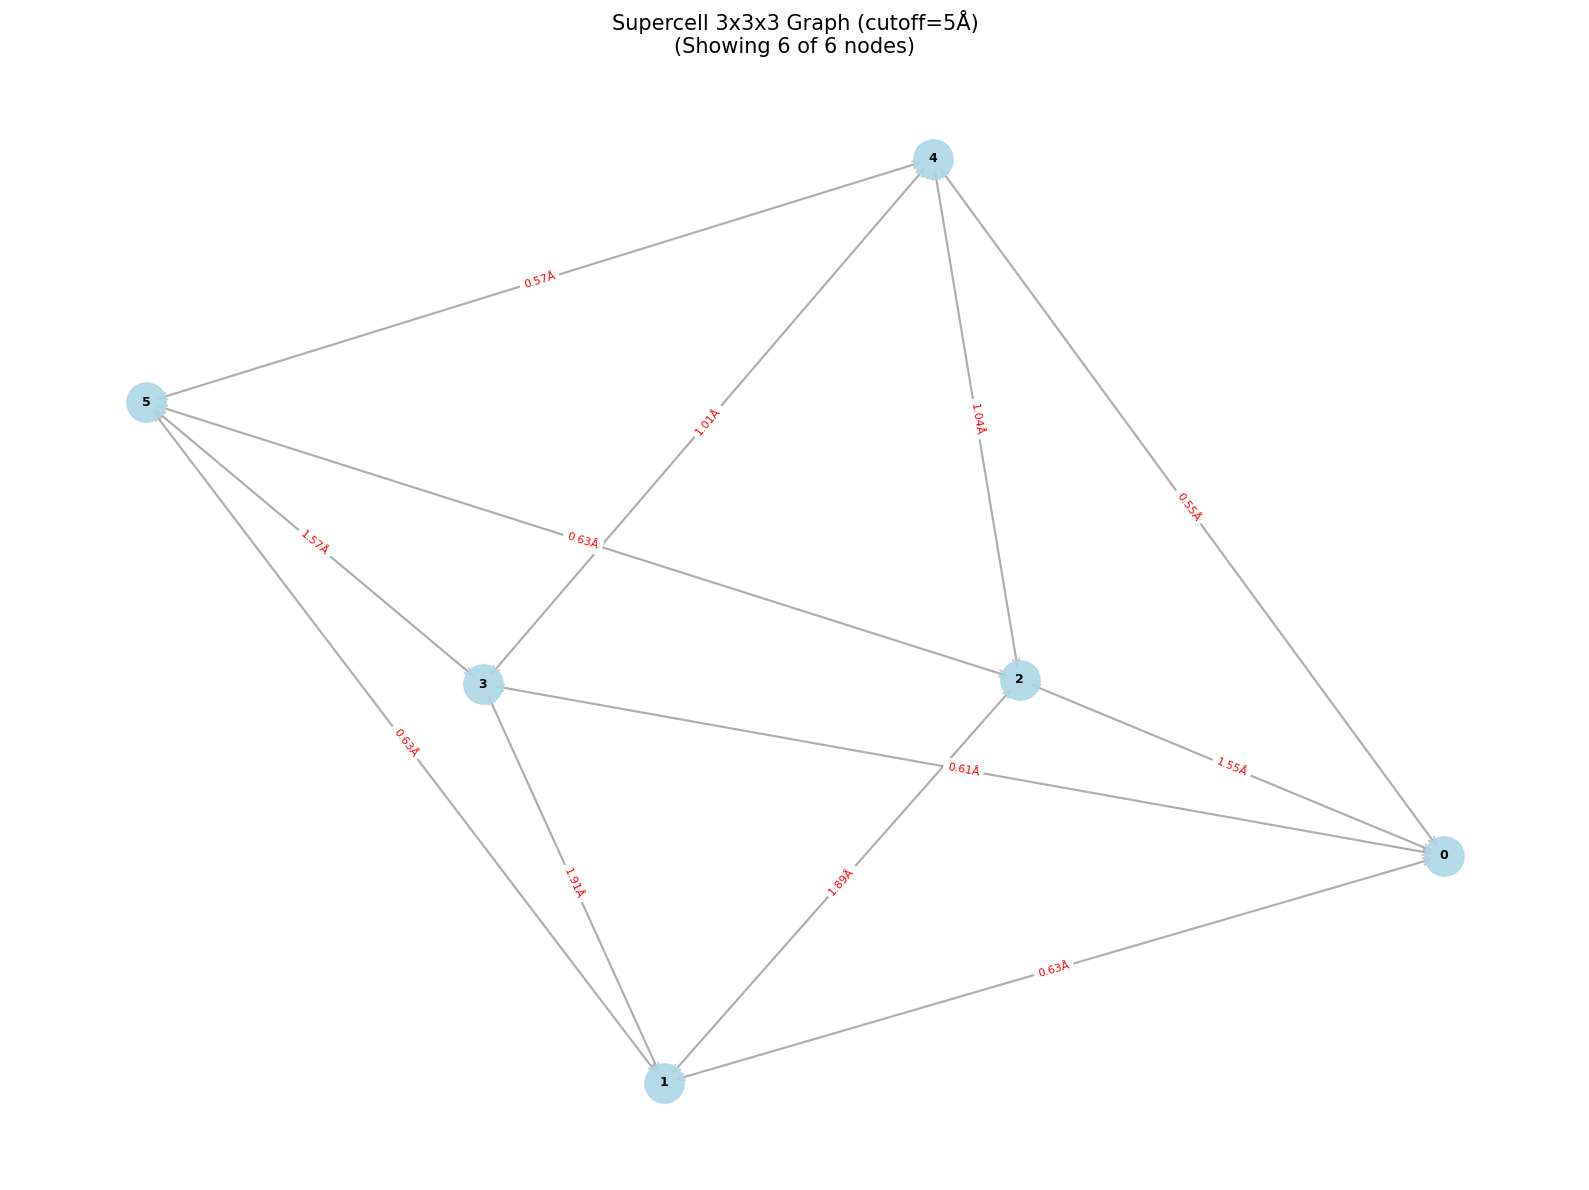

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# پیدا کردن یه ساختار بزرگتر
for idx in range(len(task.df)):
    n_atoms_check = len(task.df['structure'].iloc[idx].sites)
    if n_atoms_check ==2:
        sample_idx = idx
        break
sample_idx = 3
print(f"Using structure {sample_idx} with {n_atoms_check} atoms")

# ساخت گراف
test_graph = structure_to_graph(task.df['structure'].iloc[sample_idx], 
                                task.df['last phdos peak'].iloc[sample_idx], 
                                df_ptable)

print(f"\n📊 Graph Structure:")
print(f"   Total nodes: {test_graph.num_nodes}")
print(f"   Total edges: {test_graph.num_edges}")
print(f"   Features per node: {test_graph.num_node_features}")

# رسم گراف
G = nx.DiGraph()

# اضافه کردن نودها
for i in range(test_graph.num_nodes):
    G.add_node(i)

# اضافه کردن یال‌ها
edge_list = test_graph.edge_index.t().numpy()
edge_attrs = test_graph.edge_attr.numpy()

for idx, edge in enumerate(edge_list):
    G.add_edge(edge[0], edge[1], weight=edge_attrs[idx][0])

# رسم (فقط زیرمجموعه‌ای برای خوانایی)
subset_size = min(20, test_graph.num_nodes)
subgraph_nodes = list(range(subset_size))
H = G.subgraph(subgraph_nodes)

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(H, k=1.5, iterations=100)

nx.draw_networkx_nodes(H, pos, node_color='lightblue', node_size=800, alpha=0.9)
nx.draw_networkx_edges(H, pos, edge_color='gray', alpha=0.4, 
                       arrows=True, arrowsize=12, arrowstyle='->', width=1.5)
nx.draw_networkx_labels(H, pos, font_size=9, font_weight='bold')

# نمایش فاصله روی یال‌ها
edge_labels = {}
for u, v, data in H.edges(data=True):
    distance = data.get('weight', 0)
    edge_labels[(u, v)] = f"{distance:.2f}Å"

nx.draw_networkx_edge_labels(H, pos, edge_labels, font_size=8, font_color='red')

plt.title(f"Supercell 3x3x3 Graph (cutoff=5Å)\n(Showing {subset_size} of {test_graph.num_nodes} nodes)", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
class CustomMessagePassing(nn.Module):
    """
    لایه Message Passing سفارشی با Attention:
    پیام = attention_weight * (ویژگی_نود_همسایه * ویژگی_یال)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Attention mechanism
        # محاسبه attention score از روی: نود مقصد + نود همسایه + یال
        self.attention_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.LeakyReLU(0.2)
        )
        
        # MLP برای ترکیب پیام‌ها
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        
    def forward(self, x, edge_index, edge_attr):
        # edge_index: [2, num_edges]
        # edge_index[0]: source nodes (همسایه‌ها)
        # edge_index[1]: target nodes (نودهای مقصد)
        
        source_nodes = edge_index[0]
        target_nodes = edge_index[1]
        
        # ویژگی نودهای همسایه و مقصد
        neighbor_features = x[source_nodes]  # [num_edges, hidden_dim]
        target_features = x[target_nodes]    # [num_edges, hidden_dim]
        
        # ============ محاسبه Attention Scores ============
        # ترکیب: نود مقصد + نود همسایه + یال
        attention_input = torch.cat([target_features, neighbor_features, edge_attr], dim=1)
        attention_scores = self.attention_mlp(attention_input)  # [num_edges, 1]
        
        # ============ Softmax سریع با scatter_softmax ============
        from torch_geometric.utils import softmax
        attention_weights = softmax(attention_scores, target_nodes, num_nodes=x.size(0))
        
        # ============ ضرب ویژگی همسایه در ویژگی یال ============
        messages = neighbor_features * edge_attr  # [num_edges, hidden_dim]
        
        # ============ اعمال Attention Weights ============
        weighted_messages = messages * attention_weights  # [num_edges, hidden_dim]
        
        # ============ Aggregate Messages ============
        num_nodes = x.size(0)
        aggregated = torch.zeros(num_nodes, self.hidden_dim, device=x.device)
        aggregated.index_add_(0, target_nodes, weighted_messages)
        
        # اعمال MLP روی پیام‌های جمع شده
        output = self.message_mlp(aggregated)
        
        return output

class DualGraphGNN(nn.Module):
    """
    مدل دو گرافی: هم از گراف پیوندی هم از گراف اتمی استفاده می‌کند
    """
    def __init__(self, n_bond_features=152, n_atom_features=76, edge_dim=1):
        super().__init__()
        hidden = 32
        
        # ============ Bond Graph Branch ============
        self.bond_embedding = nn.Sequential(
            nn.Linear(n_bond_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(0.1),
        )
        
        self.bond_edge_embedding = nn.Sequential(
            nn.Linear(edge_dim, hidden),
            nn.SiLU(),
        )
        
        self.bond_message_layers = nn.ModuleList([
            CustomMessagePassing(hidden)
            for _ in range(2)
        ])
        
        self.bond_layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(2)
        ])
        
        self.bond_attention = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.SiLU(),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid()
        )
        
        # ============ Atom Graph Branch ============
        self.atom_embedding = nn.Sequential(
            nn.Linear(n_atom_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(0.1),
        )
        
        self.atom_edge_embedding = nn.Sequential(
            nn.Linear(edge_dim, hidden),
            nn.SiLU(),
        )
        
        self.atom_message_layers = nn.ModuleList([
            CustomMessagePassing(hidden)
            for _ in range(2)
        ])
        
        self.atom_layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(2)
        ])
        
        self.atom_attention = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.SiLU(),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid()
        )
        
        # ============ Pooling ============
        from torch_geometric.nn import Set2Set, global_mean_pool, global_max_pool
        self.set2set_pool = Set2Set(hidden, processing_steps=1)
        self.mean_pool = global_mean_pool
        self.max_pool = global_max_pool
        
        # ============ Global Features ============
        self.global_mlp = nn.Sequential(
            nn.Linear(1, hidden // 4),
            nn.SiLU(),
        )
        
        # ============ Final Prediction ============
        # از bond graph: 2*hidden (Set2Set) + hidden (mean) + hidden (max) = 4*hidden
        # از atom graph: 2*hidden (Set2Set) + hidden (mean) + hidden (max) = 4*hidden
        # global: hidden//4
        final_input = 8 * hidden + hidden // 4
        
        self.final_mlp = nn.Sequential(
            nn.Linear(final_input, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, bond_data, atom_data):
        # ============ Bond Graph Forward ============
        x_bond = self.bond_embedding(bond_data.x)
        edge_features_bond = self.bond_edge_embedding(bond_data.edge_attr)
        
        for i, (message_layer, layer_norm) in enumerate(zip(self.bond_message_layers, self.bond_layer_norms)):
            x_residual = x_bond
            x_bond = message_layer(x_bond, bond_data.edge_index, edge_features_bond)
            x_bond = layer_norm(x_bond)
            if i > 0:
                x_bond = x_bond + 0.3 * x_residual
            x_bond = F.silu(x_bond)
        
        attention_weights_bond = self.bond_attention(x_bond)
        x_bond_weighted = x_bond * attention_weights_bond
        
        bond_set2set = self.set2set_pool(x_bond_weighted, bond_data.batch)
        bond_mean = self.mean_pool(x_bond, bond_data.batch)
        bond_max = self.max_pool(x_bond, bond_data.batch)
        
        # ============ Atom Graph Forward ============
        x_atom = self.atom_embedding(atom_data.x)
        edge_features_atom = self.atom_edge_embedding(atom_data.edge_attr)
        
        for i, (message_layer, layer_norm) in enumerate(zip(self.atom_message_layers, self.atom_layer_norms)):
            x_residual = x_atom
            x_atom = message_layer(x_atom, atom_data.edge_index, edge_features_atom)
            x_atom = layer_norm(x_atom)
            if i > 0:
                x_atom = x_atom + 0.3 * x_residual
            x_atom = F.silu(x_atom)
        
        attention_weights_atom = self.atom_attention(x_atom)
        x_atom_weighted = x_atom * attention_weights_atom
        
        atom_set2set = self.set2set_pool(x_atom_weighted, atom_data.batch)
        atom_mean = self.mean_pool(x_atom, atom_data.batch)
        atom_max = self.max_pool(x_atom, atom_data.batch)
        
        # ============ Global Features ============
        global_features = self.global_mlp(bond_data.u)
        
        # ============ Combine & Predict ============
        combined = torch.cat([
            bond_set2set, bond_mean, bond_max,
            atom_set2set, atom_mean, atom_max,
            global_features
        ], dim=1)
        
        out = self.final_mlp(combined)
        
        return out.squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DualGraphGNN(n_bond_features=152, n_atom_features=76, edge_dim=1).to(device)
print(f"✅ Dual Graph GNN Model: {sum(p.numel() for p in model.parameters()):,} params")
print(f"   Features:")
print(f"   - Bond graph (nodes=bonds, edges=angles)")
print(f"   - Atom graph (nodes=atoms, edges=distances)")
print(f"   - Separate message passing for each graph")
print(f"   - Combined pooling + MLP")


✅ Dual Graph GNN Model: 141,303 params
   Features:
   - Bond graph (nodes=bonds, edges=angles)
   - Atom graph (nodes=atoms, edges=distances)
   - Separate message passing for each graph
   - Combined pooling + MLP


In [16]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for bond_data, atom_data in loader:
        bond_data = bond_data.to(device)
        atom_data = atom_data.to(device)
        optimizer.zero_grad()
        pred = model(bond_data, atom_data)
        loss = F.mse_loss(pred, bond_data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * bond_data.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bond_data, atom_data in loader:
            bond_data = bond_data.to(device)
            atom_data = atom_data.to(device)
            preds.extend(model(bond_data, atom_data).cpu().numpy())
            targets.extend(bond_data.y.cpu().numpy())
    return mean_absolute_error(targets, preds)

print("✅ Training functions ready")

✅ Training functions ready


In [19]:
from tqdm import tqdm

# Get fold 0 data
fold_num = 0
train_inputs, train_outputs = task.get_train_and_val_data(fold_num)
test_inputs, test_outputs = task.get_test_data(fold_num, include_target=True)

# Convert to graphs
print(f"Converting {len(train_inputs)} train structures to graphs...")
train_bond_graphs = []
train_atom_graphs = []
for i in tqdm(range(len(train_inputs))):
    bond_graph = structure_to_graph(train_inputs.iloc[i], train_outputs.iloc[i], df_ptable)
    atom_graph = structure_to_graph2(train_inputs.iloc[i], train_outputs.iloc[i], df_ptable)
    train_bond_graphs.append(bond_graph)
    train_atom_graphs.append(atom_graph)

print(f"Converting {len(test_inputs)} test structures to graphs...")
test_bond_graphs = []
test_atom_graphs = []
for i in tqdm(range(len(test_inputs))):
    bond_graph = structure_to_graph(test_inputs.iloc[i], test_outputs.iloc[i], df_ptable)
    atom_graph = structure_to_graph2(test_inputs.iloc[i], test_outputs.iloc[i], df_ptable)
    test_bond_graphs.append(bond_graph)
    test_atom_graphs.append(atom_graph)


Converting 1012 train structures to graphs...


100%|██████████| 1012/1012 [00:44<00:00, 22.72it/s]


Converting 253 test structures to graphs...


100%|██████████| 253/253 [00:08<00:00, 29.66it/s]


In [ ]:

# Create loaders
train_dataset = list(zip(train_bond_graphs, train_atom_graphs))
test_dataset = list(zip(test_bond_graphs, test_atom_graphs))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Train model
model = DualGraphGNN(n_bond_features=76, n_atom_features=76, edge_dim=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler with better patience
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.01, epochs=1000, steps_per_epoch=len(train_loader),
    pct_start=0.3, anneal_strategy='cos', div_factor=25.0, final_div_factor=1e4
)

print(f"\n🚀 Training dual graph model...")
best_mae = float('inf')
patience = 0
max_patience = 200

for epoch in range(1000):
    # Train
    model.train()
    total_loss = 0
    for bond_data, atom_data in train_loader:
        bond_data = bond_data.to(device)
        atom_data = atom_data.to(device)
        optimizer.zero_grad()
        
        pred = model(bond_data, atom_data)
        loss = F.mse_loss(pred, bond_data.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * bond_data.num_graphs
    
    train_loss = total_loss / len(train_dataset)
    
    # Evaluate every 5 epochs
    if epoch % 5 == 0 or epoch == 199:
        test_mae = evaluate(model, test_loader, device)
        current_lr = optimizer.param_groups[0]['lr']
        
        if test_mae < best_mae:
            best_mae = test_mae
            patience = 0
            torch.save(model.state_dict(), f'best_matbench_model_fold{fold_num}.pt')
            print(f"✓ Epoch {epoch:3d} | Train: {train_loss:.2f} | Test: {test_mae:.2f} ⭐ | LR: {current_lr:.6f}")
        else:
            patience += 5
            if epoch % 20 == 0:
                print(f"  Epoch {epoch:3d} | Train: {train_loss:.2f} | Test: {test_mae:.2f} | LR: {current_lr:.6f}")
        
        if patience >= max_patience:
            print(f"\n⚠️ Early stop at epoch {epoch}")
            break

print(f"\n✅ Best MAE: {best_mae:.2f} cm⁻¹")



🚀 Training dual graph model...
✓ Epoch   0 | Train: 556681.54 | Test: 616.49 ⭐ | LR: 0.000400
✓ Epoch   5 | Train: 534943.06 | Test: 594.77 ⭐ | LR: 0.000409
✓ Epoch  10 | Train: 488651.69 | Test: 548.76 ⭐ | LR: 0.000432
✓ Epoch  15 | Train: 416316.76 | Test: 470.71 ⭐ | LR: 0.000467
✓ Epoch  20 | Train: 322062.27 | Test: 372.94 ⭐ | LR: 0.000516
